In [ ]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np

#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-08-13 13:26:32.701057: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-13 13:26:32.705257: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-08-13 13:26:32.705269: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [1]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

In [6]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

In [8]:
%connect_info

{"key":"12c1bfa9-75d9-4962-b3d2-44005161986a","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9000,"control_port":9001,"shell_port":9002,"stdin_port":9003,"iopub_port":9004,"kernel_name":"python31016jvsc74a57bd0b71eef3b796cab37659ad168e2163a589827762b4b27092587cda3d063c30fd2"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing /run/user/18716/jupyter/runtime/kernel-v3743752ebddc9dd2c50286b587146bf0a237bc979.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


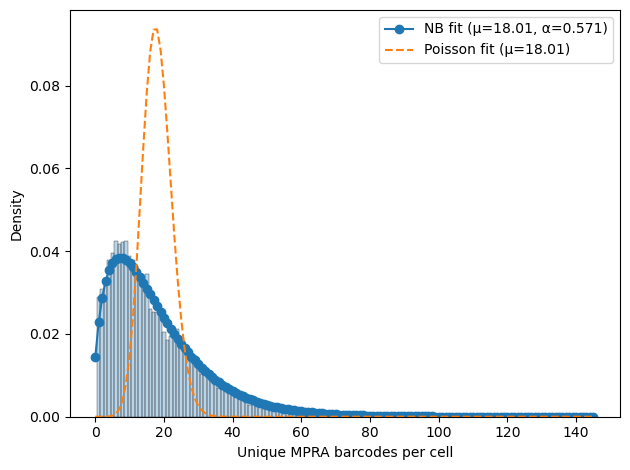

In [15]:
primordial.training_data.describe_transfection(plot=True)

In [ ]:

def from_ortho(inp:scm.ortho)->scm.Bounds:
    """
    Takes an ortho object and abstracts out its bounds.
    returns a bounds.Bounds object, naturally.

    This is an aggregation function and will hang if ortho is not done fitting yet. 
    
    This function requires that the ortho still have its training data 
    so we can extract things like "number of cells per cell-type" and 
    "number of MPRA barcodes per cell".
    """
    
    ret=scm.Bounds()

    #get the min & max nb parameters across all models
    mins=[]
    maxes=[]
    
    #for each model class
    for var in ["by_cell_type_parameters","by_cre_parameters"]:
        ## nb min & max ##
        for key in getattr(inp,var).nb:
            current=getattr(inp,var).nb[key].result()
            maxes.append(float(current.max()))
            mins.append(float(current.min()))
        
        thetas=[]
        for key in getattr(inp,var).theta:
            current=getattr(inp,var).theta[key].result()
            thetas.append(current)
        
        ## theta means ##
        #we could munge the strings & use setattr but i think this is more readable
        if var=="by_cell_type_parameters":
            ret.by_cell_type_theta=np.mean(thetas)
        elif var=="by_cre_parameters":
            ret.by_cre_theta=np.mean(thetas)

    
    #min & max nb and add to the return object
    ret.min_mpra_umi=min(mins)
    ret.max_mpra_umi=max(maxes)

    ret.theta=np.mean(ret.by_cell_type_theta,ret.by_cre_theta)

    ## Parameters from training data ##    
    tfection_params=inp.training_data.describe_transfection()
    ret.transfection_nb_mu=tfection_params["nb_mu"]
    ret.transfection_nb_alpha=tfection_params["nb_alpha"]
    

    return ret

def description_from_bounds(inp:scm.Bounds,
                            type="simple_spread",
                            nb_override=None):
    """
    Returns a primordial description dask dataframe

    and a hypothesis set describing the (unimplemented)
    
    Only type implemented for now is `simple_spread`
    - tiles CREs over the bounds range 
    other will be 
    - `override` : allowing you to specify exactly what nb param
    """

    #known before you start or "to be optimized":
    #  cells per cell-type is a fixed parameter
    #  barcodes per CRE is a fixed parameter
    
    #for each cell type, cell, decide how many MPRA barcodes are transfected.
    #note that MOI here is measured, not applied MOI. Transfection inefficiencies
    #Will effectively reduce MOI from what is applied. 
    #probably the way to do it is
    # - calculate fraction of cells with 0, 1, 2, 3... barcodes
    # - multiple fractions by total number of cells & round
    # - make a table with n=total_cells cell barcodes
    # - add number of barcodes in each cell as a column according to fraction (n_transfected).
    # - randomize row order
    # - assign cell_type based on proportions
    # - randomly sample n_transfected MPRA barcodes for each row, then convert to tall
    # - merge in CRE identity 

    #for a non-tfection reporter setup, extend to 'all-by-all' (all mpra BC by all ) filling in zeroes

    #The output will look like a describe_primordial description dataframe. 
    pass


In [ ]:


def plot_transfection_distribution():
    """
    Plots a histogram of frequency of cells with n transfected constructs
    (transfection proxied by number of unique MPRA barcodes per cell.)
    
    """

,Unnamed: 0,cell_bc,rep_id,cre_id,cell_type,umis_mpra_bc,cre_id_original
0,0,AAAAAAAAAAAAAAAA,1,everybody,blood,74,everybody
1,1,AAAAAAAAAAAAAAAC,1,everybody,blood,255,everybody
2,2,AAAAAAAAAAAAAAAG,1,everybody,blood,101,everybody
3,3,AAAAAAAAAAAAAAAT,1,everybody,blood,27,everybody
4,4,AAAAAAAAAAAAAACA,1,everybody,blood,101,everybody
...,...,...,...,...,...,...,...
41966,41966,AAAAAAAAACAGGTAG,3,reference,reference,6,weak
41967,41967,AAAAAAAAACAGGTAT,3,reference,reference,0,weak
41968,41968,AAAAAAAAACAGGTCA,3,reference,reference,2,weak
41969,41969,AAAAAAAAACAGGTCC,3,reference,reference,4,weak


In [5]:
xyz.training_data.data

,Unnamed: 0,cell_bc,rep_id,cre_id,cell_type,umis_mpra_bc,cre_id_original
0,0,AAAAAAAAAAAAAAAA,1,everybody,blood,74,everybody
1,1,AAAAAAAAAAAAAAAC,1,everybody,blood,255,everybody
2,2,AAAAAAAAAAAAAAAG,1,everybody,blood,101,everybody
3,3,AAAAAAAAAAAAAAAT,1,everybody,blood,27,everybody
4,4,AAAAAAAAAAAAAACA,1,everybody,blood,101,everybody
...,...,...,...,...,...,...,...
41966,41966,AAAAAAAAACAGGTAG,3,reference,reference,6,weak
41967,41967,AAAAAAAAACAGGTAT,3,reference,reference,0,weak
41968,41968,AAAAAAAAACAGGTCA,3,reference,reference,2,weak
41969,41969,AAAAAAAAACAGGTCC,3,reference,reference,4,weak


In [6]:
b=from_ortho(xyz)

In [7]:
b

Bounds(metadata=None, min_mpra_umi=1.977178826507623, max_mpra_umi=221.90297054935553, by_cre_theta=None, by_cell_type_theta=3.2166202, num_cres=None, cells_per_cell_type=None, moi=None)

In [3]:
dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_v3.tsv")
dat.ortho_filter()
dat.set_negative_controls(["nobody","weak"])
dat.set_reference_cell("liver")
primordial=scm.ortho()
primordial.criss_cross(client,dat=dat)
primordial.extract_params(client)

scMPRAforge: INFO: Dropped 0 of 27 (cell_type, cre_id) combos with fewer than 3 nonzero entries.


In [4]:
primordial.save(".","test_save")

3.2567084
3.396007
3.3175333
3.2008197
2.1678116
3.2843478
3.2969668
3.3159997


In [11]:
xyz.training_data.data["umis_mpra_bc"]

0         74
1        255
2        101
3         27
4        101
        ... 
41966      6
41967      0
41968      2
41969      4
41970      0
Name: umis_mpra_bc, Length: 41971, dtype: int64

In [21]:
min(mins)

2.0135518849371543

In [25]:
cluster.close()